In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from datetime import datetime

Importing the data

In [2]:
# Load the dataset
df = pd.read_csv('bus_eta_dataset.csv')

# Display the first few rows of the dataset
df.head()

,timestamp,bus_id,route_id,stop_sequence,current_stop_name,next_stop_name,day_of_week,is_holiday,is_peak_hour,weather_condition,passenger_count,current_speed,traffic_condition,distance_to_next_stop,current_lat,current_lon,eta_minutes
0,2024-01-01 06:00:00,BUS_001,R001,1,UTAR bus stop,KJ370 Perumahan SG Long Seksyen 7,0,False,False,sunny,22,18.07,jam,0.39,3.044544,101.794874,1
1,2024-01-01 06:05:00,BUS_001,R001,2,KJ370 Perumahan SG Long Seksyen 7,KJ428 SMK SG Long,0,False,False,rainy,15,17.49,heavy,0.24,3.047666,101.796650,0
2,2024-01-01 06:10:00,BUS_001,R001,3,KJ428 SMK SG Long,Green Acre Condo,0,False,False,rainy,6,39.61,light,0.47,3.045477,101.798123,0
3,2024-01-01 06:17:00,BUS_001,R001,4,Green Acre Condo,SG Long Club House,0,False,False,windy,17,44.45,light,0.27,3.042788,101.798283,0
4,2024-01-01 06:23:00,BUS_001,R001,5,SG Long Club House,UTAR bus stop,0,False,False,windy,15,13.64,jam,0.53,3.042749,101.796945,2


Data Quality check 

In [3]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)

Missing Values:
 timestamp                0
bus_id                   0
route_id                 0
stop_sequence            0
current_stop_name        0
next_stop_name           0
day_of_week              0
is_holiday               0
is_peak_hour             0
weather_condition        0
passenger_count          0
current_speed            0
traffic_condition        0
distance_to_next_stop    0
current_lat              0
current_lon              0
eta_minutes              0
dtype: int64


In [4]:
# Check for duplicated rows
duplicated_rows = df.duplicated().sum()
print("Number of Duplicated Rows:", duplicated_rows)

Number of Duplicated Rows: 0


In [5]:
# Explore unique values in each column
unique_values = {col: df[col].unique() for col in df.columns}
print("Unique Values:\n", unique_values)

Unique Values:
 {'timestamp': array(['2024-01-01 06:00:00', '2024-01-01 06:05:00',
       '2024-01-01 06:10:00', ..., '2025-08-09 14:07:00',
       '2025-08-09 14:12:00', '2025-08-09 14:18:00'], dtype=object), 'bus_id': array(['BUS_001', 'BUS_002', 'BUS_003', 'BUS_004', 'BUS_005'],
      dtype=object), 'route_id': array(['R001'], dtype=object), 'stop_sequence': array([1, 2, 3, 4, 5]), 'current_stop_name': array(['UTAR bus stop', 'KJ370 Perumahan SG Long Seksyen 7',
       'KJ428 SMK SG Long', 'Green Acre Condo', 'SG Long Club House'],
      dtype=object), 'next_stop_name': array(['KJ370 Perumahan SG Long Seksyen 7', 'KJ428 SMK SG Long',
       'Green Acre Condo', 'SG Long Club House', 'UTAR bus stop'],
      dtype=object), 'day_of_week': array([0, 1, 2, 3, 4, 5, 6]), 'is_holiday': array([False,  True]), 'is_peak_hour': array([False,  True]), 'weather_condition': array(['sunny', 'rainy', 'windy', 'storm', 'foggy'], dtype=object), 'passenger_count': array([22, 15,  6, 17, 13, 18, 10, 12,

In [6]:
# Data Type Validation
print("1. Data Type Check:")
print(df.dtypes)

1. Data Type Check:
timestamp                 object
bus_id                    object
route_id                  object
stop_sequence              int64
current_stop_name         object
next_stop_name            object
day_of_week                int64
is_holiday                  bool
is_peak_hour                bool
weather_condition         object
passenger_count            int64
current_speed            float64
traffic_condition         object
distance_to_next_stop    float64
current_lat              float64
current_lon              float64
eta_minutes                int64
dtype: object


In [7]:
# Convert timestamp to datetime if not already
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Check if numeric columns are actually numeric
numeric_cols = ['passenger_count', 'current_speed', 'distance_to_next_stop', 
                'current_lat', 'current_lon', 'eta_minutes']
for col in numeric_cols:
    non_numeric = pd.to_numeric(df[col], errors='coerce').isna().sum()
    print(f"Non-numeric values in {col}: {non_numeric}")

Non-numeric values in passenger_count: 0
Non-numeric values in current_speed: 0
Non-numeric values in distance_to_next_stop: 0
Non-numeric values in current_lat: 0
Non-numeric values in current_lon: 0
Non-numeric values in eta_minutes: 0


In [8]:
# Range/Boundary Checks
# Check passenger counts for reasonable values
print(f"Min passenger count: {df['passenger_count'].min()}, Max: {df['passenger_count'].max()}")
# Check speed values
print(f"Min speed: {df['current_speed'].min()}, Max: {df['current_speed'].max()}")
# Check coordinates
print(f"Latitude range: {df['current_lat'].min()} to {df['current_lat'].max()}")
print(f"Longitude range: {df['current_lon'].min()} to {df['current_lon'].max()}")

Min passenger count: 0, Max: 50
Min speed: 5.0, Max: 60.0
Latitude range: 3.041484 to 3.0481
Longitude range: 101.794788 to 101.798641


In [9]:
# Consistency Checks
# Check if is_peak_hour matches typical peak hours
df['hour'] = df['timestamp'].dt.hour
peak_mismatch = df[((df['hour'] >= 7) & (df['hour'] <= 9) & (df['is_peak_hour'] == False)) | 
                   ((df['hour'] < 7) & (df['hour'] > 9) & (df['is_peak_hour'] == True))]
print(f"Potential peak hour inconsistencies: {len(peak_mismatch)}")
# Check if day_of_week is consistent with timestamp
df['actual_day'] = df['timestamp'].dt.weekday
day_mismatch = df[df['day_of_week'] != df['actual_day']]
print(f"Day of week inconsistencies: {len(day_mismatch)}")

Potential peak hour inconsistencies: 5005
Day of week inconsistencies: 0


EDA

In [10]:
# Outlier Detection
print("Outlier Detection:")
# Using IQR method for outliers
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))]
    print(f"Outliers in {col}: {len(outliers)}")

Outlier Detection:
Outliers in passenger_count: 3671
Outliers in current_speed: 0
Outliers in distance_to_next_stop: 0
Outliers in current_lat: 0
Outliers in current_lon: 0
Outliers in eta_minutes: 8387


In [11]:
# Time Series Checks
print("\nTime Series Checks:")
# Check for time gaps or irregularities
df_sorted = df.sort_values(['bus_id', 'timestamp'])
df_sorted['time_diff'] = df_sorted.groupby('bus_id')['timestamp'].diff().dt.total_seconds().div(60)
print(f"Time differences statistics (minutes):")
print(df_sorted['time_diff'].describe())


Time Series Checks:
Time differences statistics (minutes):
count    99995.000000
mean        42.213581
std         96.942165
min          5.000000
25%          5.000000
50%          6.000000
75%          7.000000
max        679.000000
Name: time_diff, dtype: float64


In [12]:
# Check for chronological inconsistencies within bus routes
for bus in df['bus_id'].unique():
    bus_data = df[df['bus_id'] == bus].sort_values('timestamp')
    if not bus_data['stop_sequence'].is_monotonic_increasing:
        print(f"Non-monotonic stop sequence for {bus}")

Non-monotonic stop sequence for BUS_001
Non-monotonic stop sequence for BUS_002
Non-monotonic stop sequence for BUS_003
Non-monotonic stop sequence for BUS_004
Non-monotonic stop sequence for BUS_005


In [13]:
# Logical Relationship Validation
print("\nLogical Relationship Validation:")
# Check if eta makes sense with speed and distance
df['calculated_eta'] = (df['distance_to_next_stop'] / df['current_speed']) * 60  # minutes
large_eta_diff = df[abs(df['calculated_eta'] - df['eta_minutes']) > 2]
print(f"Potential ETA inconsistencies: {len(large_eta_diff)}")


Logical Relationship Validation:
Potential ETA inconsistencies: 511


In [14]:
# Check if traffic condition matches speed
speed_traffic_mismatch = df[
    ((df['traffic_condition'] == 'jam') & (df['current_speed'] > 30)) |
    ((df['traffic_condition'] == 'light') & (df['current_speed'] < 10))
]
print(f"Speed-traffic condition mismatches: {len(speed_traffic_mismatch)}")

Speed-traffic condition mismatches: 3



Statistical Distribution Analysis:
                           timestamp  stop_sequence   day_of_week  \
count                         100000  100000.000000  100000.00000   
mean   2024-10-20 05:30:43.342199808       2.988910       2.99254   
min              2024-01-01 06:00:00       1.000000       0.00000   
25%              2024-05-26 13:40:30       2.000000       1.00000   
50%              2024-10-19 22:48:00       3.000000       3.00000   
75%              2025-03-15 19:26:15       4.000000       5.00000   
max              2025-08-09 14:18:00       5.000000       6.00000   
std                              NaN       1.414449       1.99766   

       passenger_count  current_speed  distance_to_next_stop    current_lat  \
count    100000.000000  100000.000000          100000.000000  100000.000000   
mean         20.473840      30.388755               0.379676       3.045086   
min           0.000000       5.000000               0.240000       3.041484   
25%          14.000000    

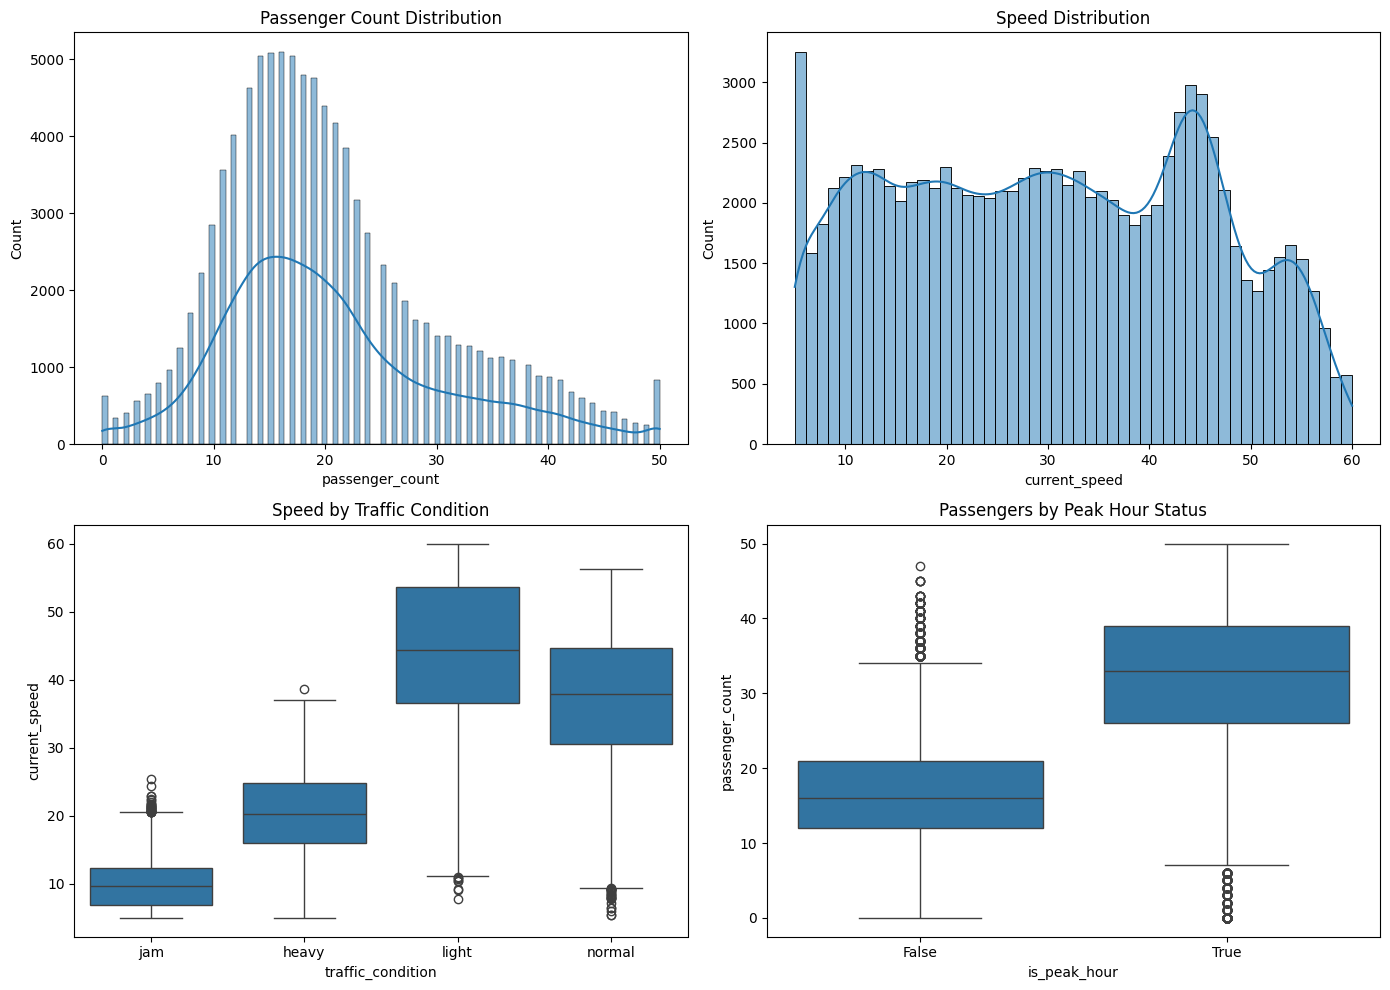

In [15]:
# Statistical Distribution Analysis
print("\nStatistical Distribution Analysis:")
print(df.describe())

# Visualize key distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(df['passenger_count'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Passenger Count Distribution')

sns.histplot(df['current_speed'], kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Speed Distribution')

sns.boxplot(x='traffic_condition', y='current_speed', data=df, ax=axes[1, 0])
axes[1, 0].set_title('Speed by Traffic Condition')

sns.boxplot(x='is_peak_hour', y='passenger_count', data=df, ax=axes[1, 1])
axes[1, 1].set_title('Passengers by Peak Hour Status')

plt.tight_layout()
plt.show()

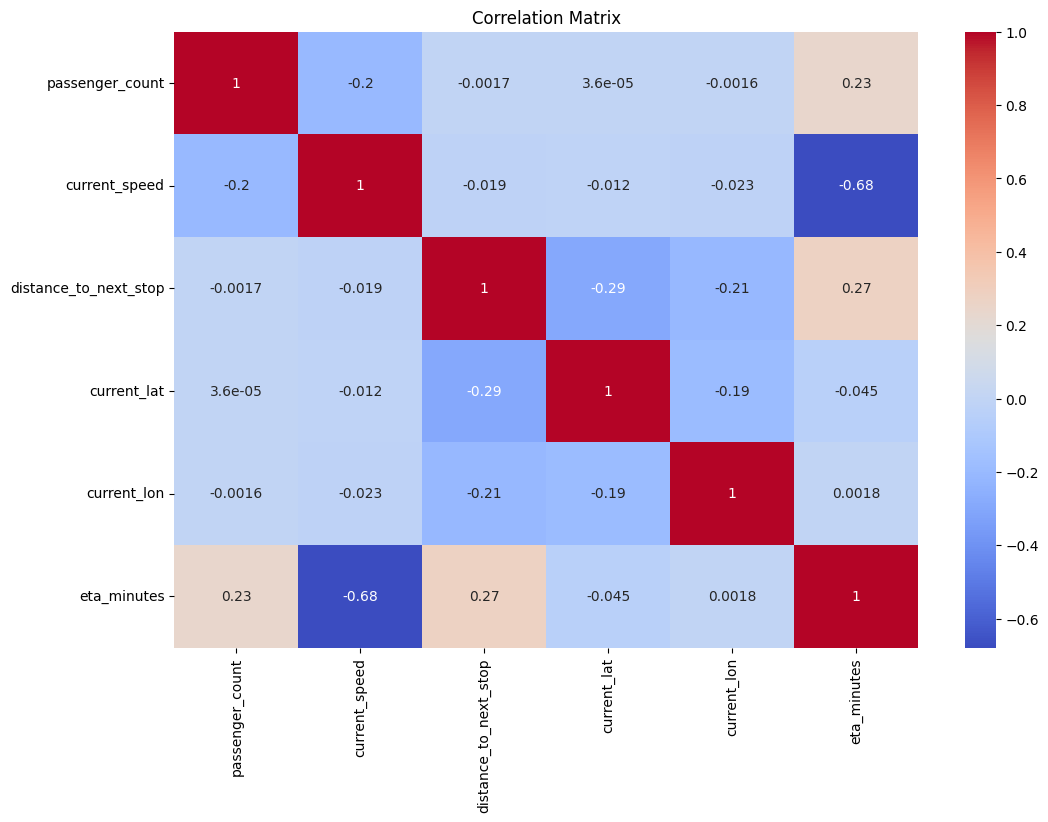

In [16]:
# Correlation matrix of numeric variables
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

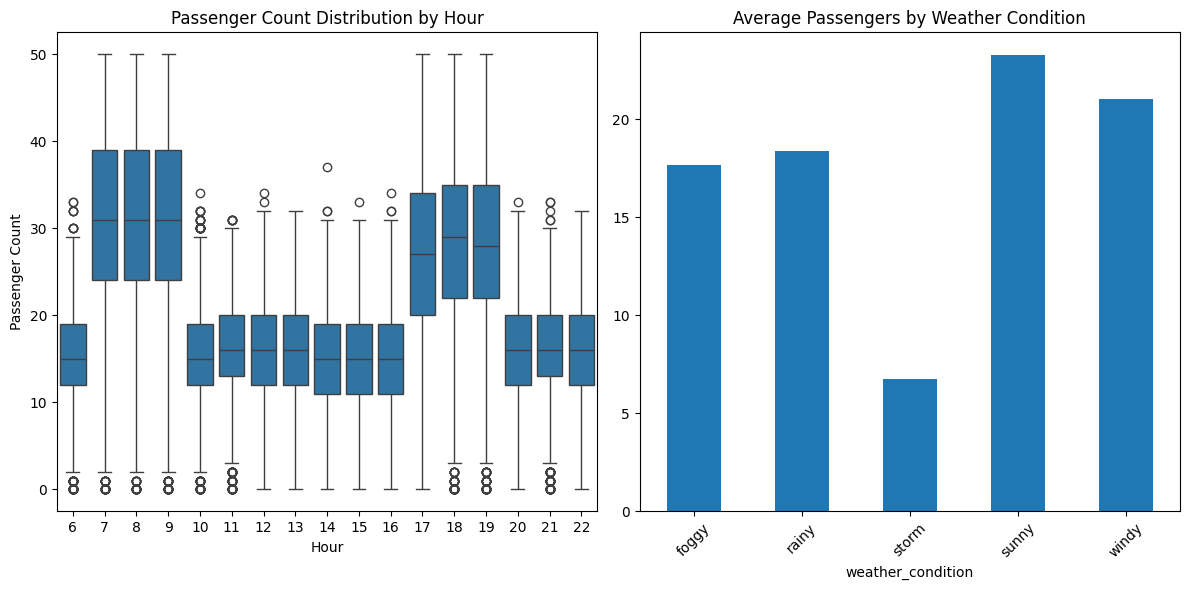

In [ ]:
# Passenger analysis
plt.figure(figsize=(12, 6))
    
# Passenger count by hour
plt.subplot(1, 2, 1)
sns.boxplot(x='hour', y='passenger_count', data=df)
plt.title('Passenger Count Distribution by Hour')
plt.xlabel('Hour')
plt.ylabel('Passenger Count')
    
# Average passengers by weather
plt.subplot(1, 2, 2)
df.groupby('weather_condition')['passenger_count'].mean().plot(kind='bar')
plt.title('Average Passengers by Weather Condition')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

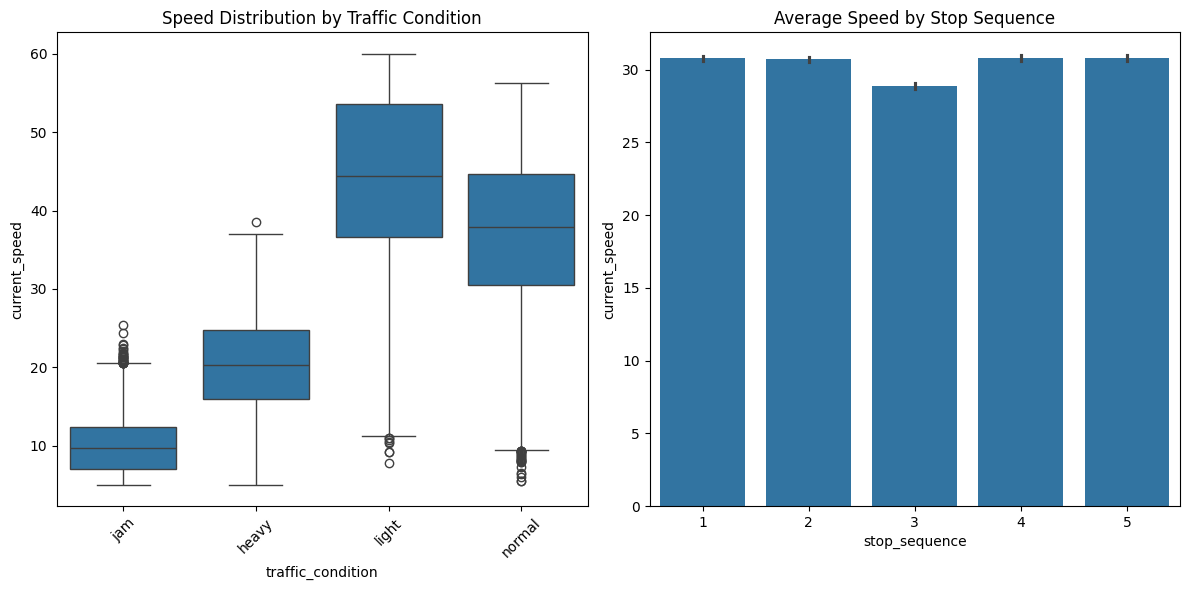

In [19]:
# Speed and traffic analysis
plt.figure(figsize=(12, 6))
    
# Speed by traffic condition
plt.subplot(1, 2, 1)
sns.boxplot(x='traffic_condition', y='current_speed', data=df)
plt.title('Speed Distribution by Traffic Condition')
plt.xticks(rotation=45)
    
# Average speed by stop sequence
plt.subplot(1, 2, 2)
sns.barplot(x='stop_sequence', y='current_speed', data=df)
plt.title('Average Speed by Stop Sequence')
plt.tight_layout()
plt.show()

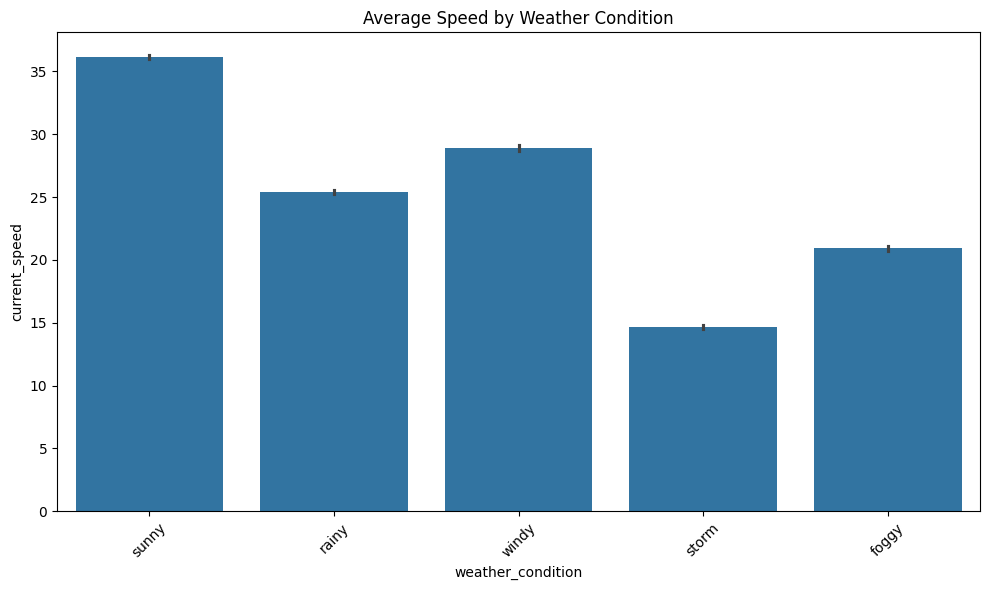

In [20]:
# Weather impact analysis
plt.figure(figsize=(10, 6))
    
# Average speed by weather
sns.barplot(x='weather_condition', y='current_speed', data=df)
plt.title('Average Speed by Weather Condition')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Route analysis
# Calculate average time between stops
route_analysis = df.groupby('stop_sequence').agg({
    'distance_to_next_stop': 'mean',
    'eta_minutes': 'mean',
    'passenger_count': 'mean'
}).round(2)
    
print("\nRoute Analysis:")
print(route_analysis)